# Biblioteks

In [1]:
import re
import nltk
import random
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from collections import Counter
from wordcloud import WordCloud
from nltk.corpus import stopwords
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import learning_curve
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc

In [2]:
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\santa\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\santa\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\santa\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

# CARGA DATASETs

In [3]:
train_df = pd.read_csv("C:/Users/santa/OneDrive/Documentos/TT-2 MEJORADO FINAL/Datasets generales/df_train_sin_EDA.csv")
val_df = pd.read_csv("C:/Users/santa/OneDrive/Documentos/TT-2 MEJORADO FINAL/val_final.csv")
test_df = pd.read_csv("C:/Users/santa/OneDrive\Documentos/TT-2 MEJORADO FINAL/test_final.csv")

print("TRAIN:", train_df.shape)
print("VALIDATION:", val_df.shape)
print("TEST:", test_df.shape)

TRAIN: (73010, 2)
VALIDATION: (10508, 2)
TEST: (20967, 2)


In [4]:
train_df.duplicated().sum()

np.int64(0)

In [5]:
val_df.duplicated().sum()

np.int64(0)

In [6]:
test_df.duplicated().sum()

np.int64(0)

In [7]:
train_df.isnull().sum()

tweet    0
clase    0
dtype: int64

In [8]:
val_df.isnull().sum()

tweet    0
clase    0
dtype: int64

In [9]:
test_df.isnull().sum()

tweet    0
clase    0
dtype: int64

# Distribución de clases

C:\Users\santa\AppData\Local\Temp\ipykernel_6000\2201912865.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


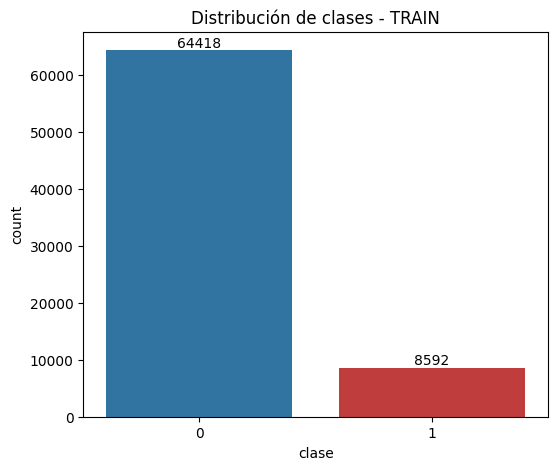

C:\Users\santa\AppData\Local\Temp\ipykernel_6000\2201912865.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


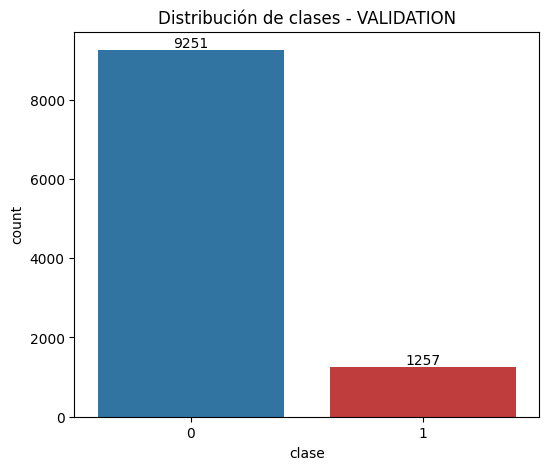

C:\Users\santa\AppData\Local\Temp\ipykernel_6000\2201912865.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


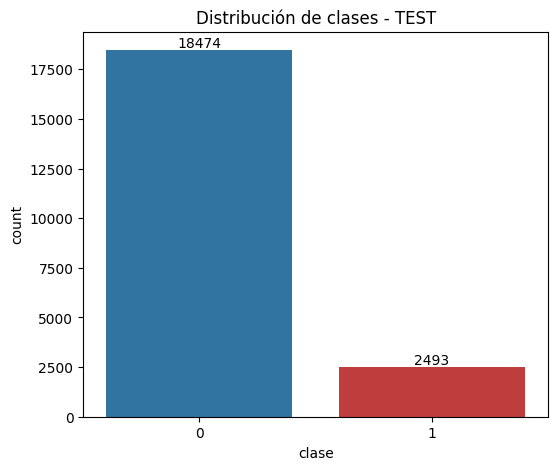

In [10]:
def grafica_clases(df, nombre):
    plt.figure(figsize=(6, 5))
    ax = sns.countplot(
        data=df,
        x='clase',
        palette=['#1f77b4', '#d62728']
    )

    for p in ax.patches:
        ax.annotate(
            int(p.get_height()),
            (p.get_x() + p.get_width() / 2, p.get_height()),
            ha='center',
            va='bottom'
        )

    plt.title(f"Distribución de clases - {nombre}")
    plt.show()

grafica_clases(train_df, "TRAIN")
grafica_clases(val_df, "VALIDATION")
grafica_clases(test_df, "TEST")

# Nube de Palabras

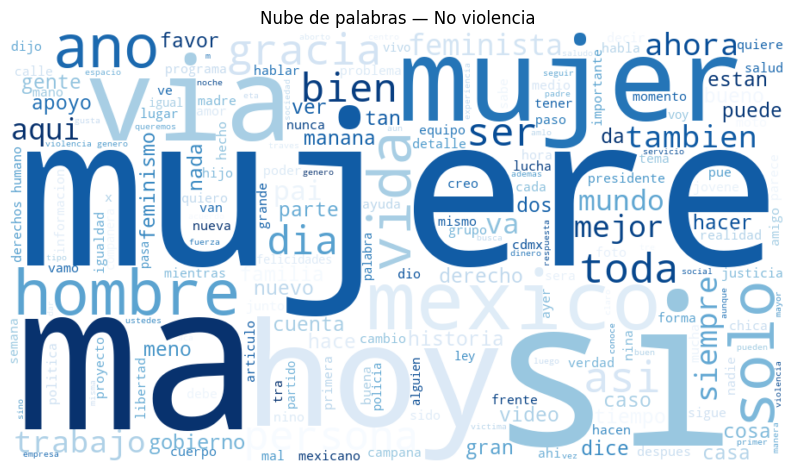

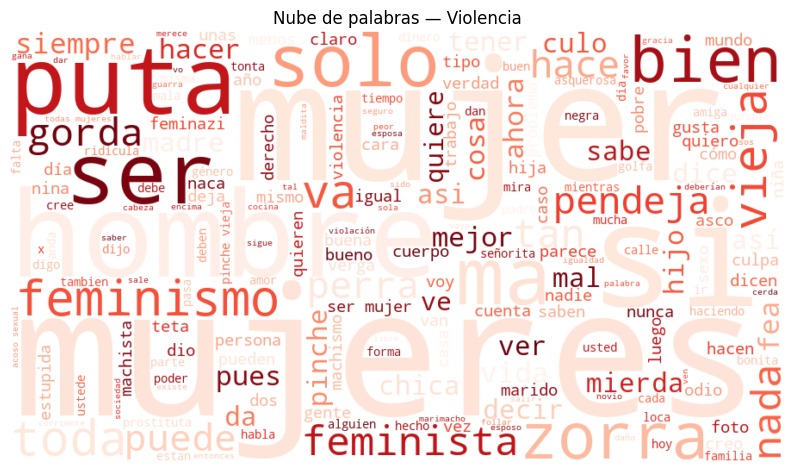

In [11]:
def nube_palabras(df, clase, color):
    texto = " ".join(df[df["clase"] == clase]["tweet"])

    nube = WordCloud(
        width=900,
        height=500,
        background_color="white",
        colormap=color
    ).generate(texto)

    plt.figure(figsize=(10, 6))
    plt.imshow(nube, interpolation="bilinear")
    plt.axis("off")

    tit = "Violencia" if clase == 1 else "No violencia"
    plt.title(f"Nube de palabras — {tit}")
    plt.show()

nube_palabras(train_df, 0, "Blues")
nube_palabras(train_df, 1, "Reds")

#Top Palabras

C:\Users\santa\AppData\Local\Temp\ipykernel_6000\3333622422.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


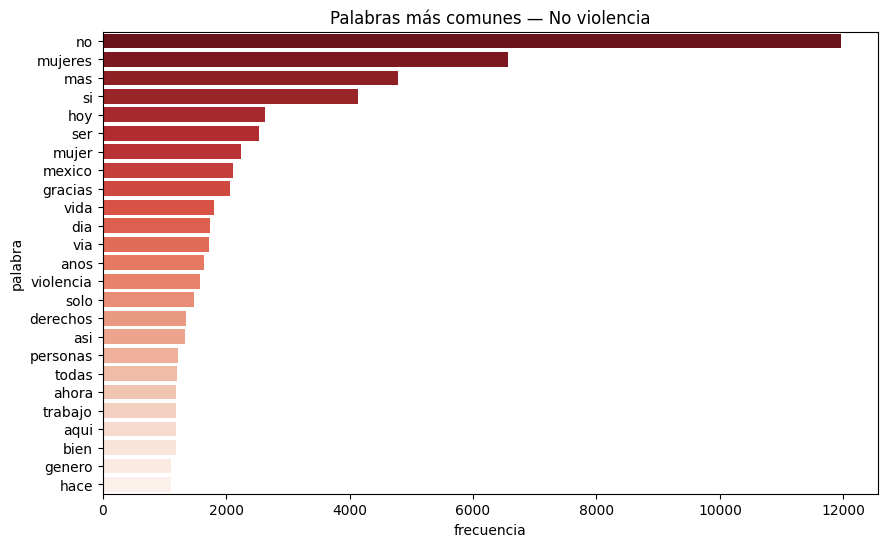

C:\Users\santa\AppData\Local\Temp\ipykernel_6000\3333622422.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


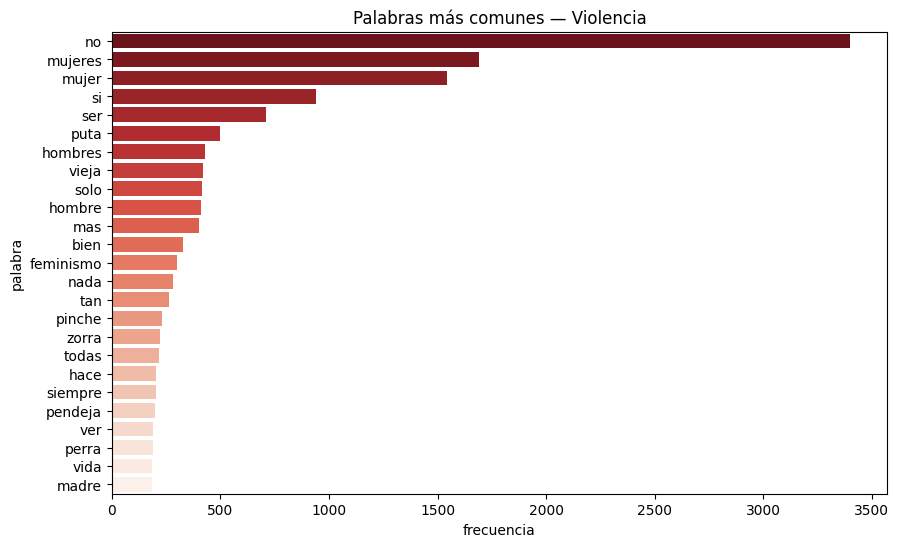

In [12]:
def top_palabras(df, clase, n=25):
    palabras = " ".join(df[df["clase"] == clase]["tweet"]).split()
    top = Counter(palabras).most_common(n)

    top_df = pd.DataFrame(top, columns=["palabra", "frecuencia"])

    plt.figure(figsize=(10, 6))
    sns.barplot(
        data=top_df,
        x="frecuencia",
        y="palabra",
        palette="Reds_r"
    )

    tit = "Violencia" if clase == 1 else "No violencia"
    plt.title(f"Palabras más comunes — {tit}")
    plt.show()

top_palabras(train_df, 0)
top_palabras(train_df, 1)

# Train/Test/Val

In [13]:
X_train = train_df["tweet"]
y_train = train_df["clase"]

X_val = val_df["tweet"]
y_val = val_df["clase"]

X_test = test_df["tweet"]
y_test = test_df["clase"]

In [14]:
vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(2, 3)
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_val_tfidf = vectorizer.transform(X_val)
X_test_tfidf = vectorizer.transform(X_test)

# Clasificadores

## SVM

In [15]:
svm = LinearSVC()

svm.fit(
    X_train_tfidf,
    y_train
)

,penalty,'l2'
,loss,'squared_hinge'
,dual,'auto'
,tol,0.0001
,C,1.0
,multi_class,'ovr'
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,verbose,0
,random_state,None



 VALIDACIÓN SVM
              precision    recall  f1-score   support

           0       0.90      0.99      0.95      9251
           1       0.76      0.23      0.36      1257

    accuracy                           0.90     10508
   macro avg       0.83      0.61      0.65     10508
weighted avg       0.89      0.90      0.88     10508



c:\Users\santa\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\model_selection\_validation.py:516: FitFailedWarning: 
1 fits failed out of a total of 25.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
1 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\santa\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\model_selection\_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\santa\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\base.py", line 1365, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "c:\Users\santa\AppData\Local\Programs\Python\Python310\lib\site-packages\

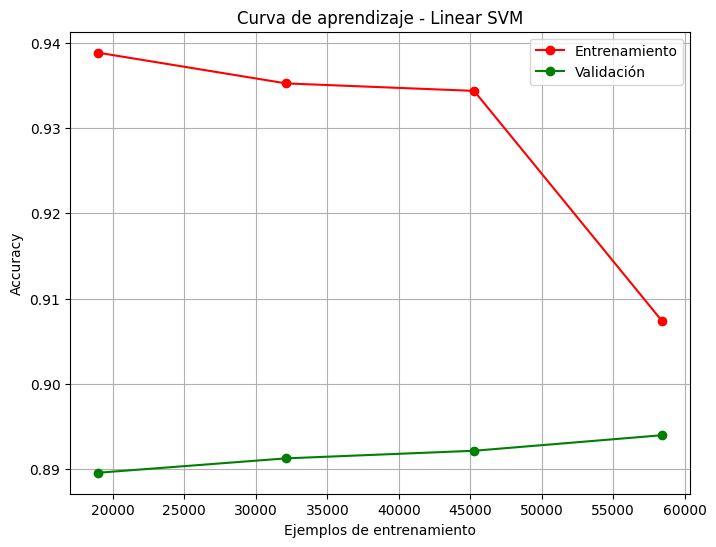

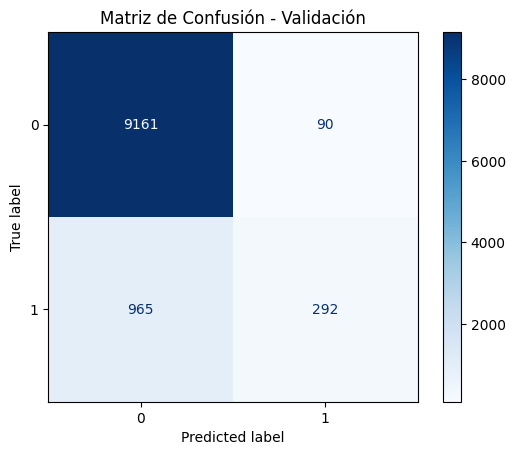

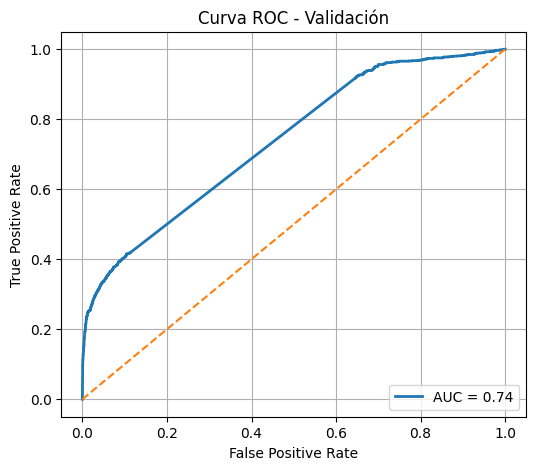

In [16]:
y_pred_val = svm.predict(
    X_val_tfidf
)

print("\n VALIDACIÓN SVM")

print(classification_report(
    y_val,
    y_pred_val
))

# CURVA DE APRENDIZAJE

train_sizes, train_scores, test_scores = learning_curve(
    svm,
    X_train_tfidf,
    y_train,
    cv=5,
    scoring='accuracy',
    train_sizes=np.linspace(
        0.1,
        1.0,
        5
    ),

    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
test_mean = test_scores.mean(axis=1)
plt.figure(figsize=(8,6))
plt.plot(
    train_sizes,
    train_mean,
    'o-',
    color='red',
    label='Entrenamiento'
)

plt.plot(
    train_sizes,
    test_mean,
    'o-',
    color='green',
    label='Validación'
)
plt.title("Curva de aprendizaje - Linear SVM")
plt.xlabel("Ejemplos de entrenamiento")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

# MATRIZ VALIDACIÓN
cm = confusion_matrix(
    y_val,
    y_pred_val
)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.title("Matriz de Confusión - Validación")
plt.show()

# ROC VALIDACIÓN

y_score = svm.decision_function(
    X_val_tfidf
)
fpr, tpr, _ = roc_curve(
    y_val,
    y_score
)

roc_auc = auc(fpr, tpr)
plt.figure(figsize=(6,5))
plt.plot(
    fpr,
    tpr,
    lw=2,
    label=f'AUC = {roc_auc:.2f}'
)

plt.plot(
    [0,1],
    [0,1],
    linestyle='--'
)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC - Validación")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()



 TEST FINAL SVM 
              precision    recall  f1-score   support

           0       0.90      0.99      0.94     18474
           1       0.72      0.22      0.33      2493

    accuracy                           0.90     20967
   macro avg       0.81      0.60      0.64     20967
weighted avg       0.88      0.90      0.87     20967



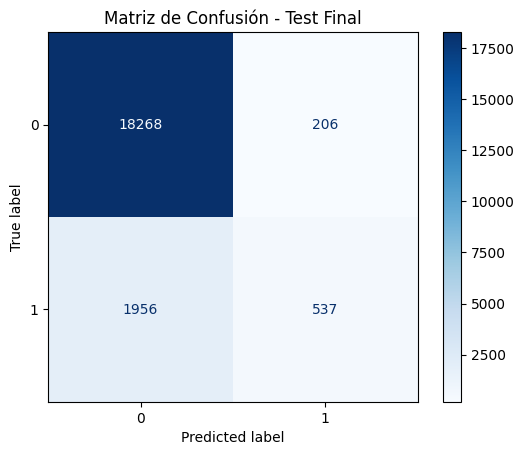

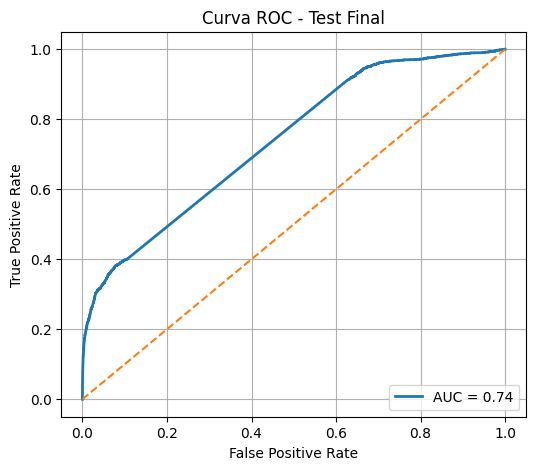

In [17]:
# TEST FINAL
y_pred_test = svm.predict(
    X_test_tfidf
)

print("\n TEST FINAL SVM ")
print(classification_report(
    y_test,
    y_pred_test
))

# MATRIZ TEST FINAL

cm_test = confusion_matrix(
    y_test,
    y_pred_test
)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_test)
disp.plot(cmap=plt.cm.Blues)
plt.title("Matriz de Confusión - Test Final")
plt.show()

# ROC TEST FINAL

y_score_test = svm.decision_function(X_test_tfidf)
fpr, tpr, _ = roc_curve(
    y_test,
    y_score_test
)

roc_auc = auc(fpr, tpr)
plt.figure(figsize=(6,5))
plt.plot(
    fpr,
    tpr,
    lw=2,
    label=f'AUC = {roc_auc:.2f}'
)
plt.plot(
    [0,1],
    [0,1],
    linestyle='--'
)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC - Test Final")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

In [18]:
# EJEMPLOS CORRECTOS E INCORRECTOS
resultados_svm = pd.DataFrame({
    "texto": X_test.reset_index(drop=True),
    "real": y_test.reset_index(drop=True),
    "prediccion": y_pred_test
})

# CORRECTOS

correctos = resultados_svm[resultados_svm["real"] == resultados_svm["prediccion"]]

print("\n")
print("="*60)
print("EJEMPLOS CORRECTOS - SVM")
print("="*60)

ejemplos_correctos = correctos.sample(
    2,
)

for i, row in ejemplos_correctos.iterrows():
    print(f"\nTEXTO:\n{row['texto']}\n")
    print(f"REAL: {row['real']}")
    print(f"PREDICCIÓN: {row['prediccion']}")
    print("-"*60)

# INCORRECTOS

incorrectos = resultados_svm[resultados_svm["real"] != resultados_svm["prediccion"]]

print("\n")
print("="*60)
print("EJEMPLOS INCORRECTOS - SVM")
print("="*60)

ejemplos_incorrectos = incorrectos.sample(
    2,
)

for i, row in ejemplos_incorrectos.iterrows():
    print(f"\nTEXTO:\n{row['texto']}\n")
    print(f"REAL: {row['real']}")
    print(f"PREDICCIÓN: {row['prediccion']}")
    print("-"*60)



EJEMPLOS CORRECTOS - SVM

TEXTO:
aparte bajon media plantilla

REAL: 0
PREDICCIÓN: 0
------------------------------------------------------------

TEXTO:
gobernador puebla afirma no presencia carteles celulas delincuentes locales

REAL: 0
PREDICCIÓN: 0
------------------------------------------------------------


EJEMPLOS INCORRECTOS - SVM

TEXTO:
puede comparar embarazo deseado violación

REAL: 1
PREDICCIÓN: 0
------------------------------------------------------------

TEXTO:
negra obesa da mas miedo presion lobbies realidad mercado

REAL: 1
PREDICCIÓN: 0
------------------------------------------------------------


## Regresión Logística

In [19]:
lr = LogisticRegression(
    C=5,
    max_iter=1000,
    random_state=42
)

# ENTRENAMIENTO

lr.fit(
    X_train_tfidf,
    y_train
)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,5
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'



 VALIDACIÓN REGRESIÓN LOGÍSTICA
              precision    recall  f1-score   support

           0       0.90      0.99      0.95      9251
           1       0.76      0.23      0.35      1257

    accuracy                           0.90     10508
   macro avg       0.83      0.61      0.65     10508
weighted avg       0.89      0.90      0.87     10508



c:\Users\santa\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\model_selection\_validation.py:516: FitFailedWarning: 
1 fits failed out of a total of 25.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
1 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\santa\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\model_selection\_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\santa\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\base.py", line 1365, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "c:\Users\santa\AppData\Local\Programs\Python\Python310\lib\site-packages\

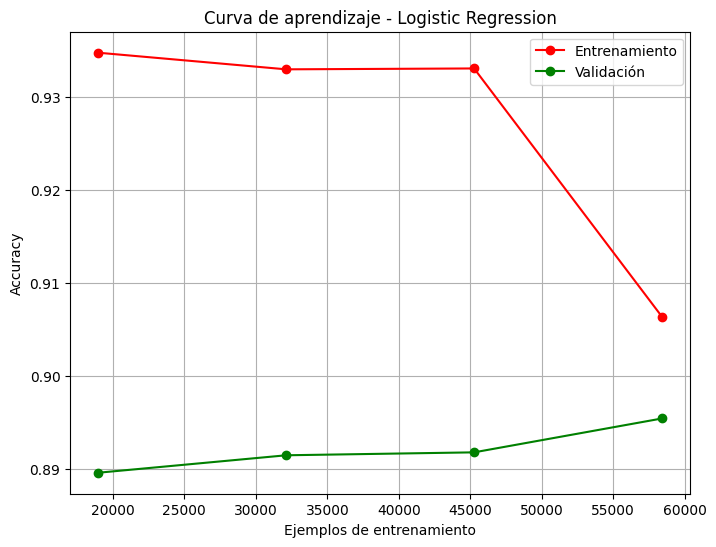

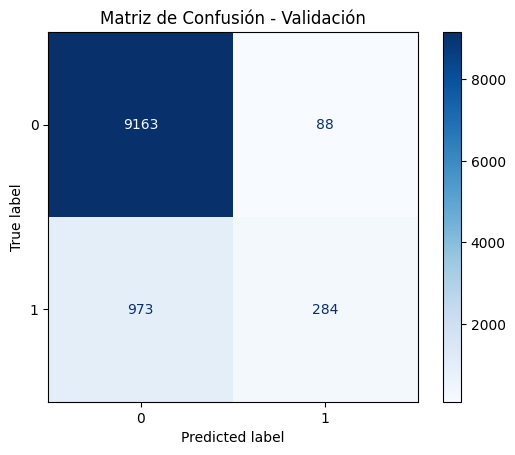

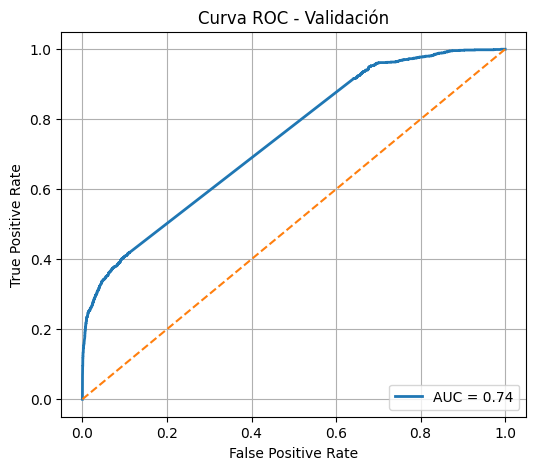

In [20]:
y_pred_val_lr = lr.predict(
    X_val_tfidf
)

print("\n VALIDACIÓN REGRESIÓN LOGÍSTICA")
print(classification_report(
    y_val,
    y_pred_val_lr
))

# CURVA DE APRENDIZAJE

train_sizes, train_scores, test_scores = learning_curve(
    lr,
    X_train_tfidf,
    y_train,
    cv=5,
    scoring='accuracy',
    train_sizes=np.linspace(
        0.1,
        1.0,
        5
    ),

    n_jobs=-1
)

train_mean_lr = train_scores.mean(axis=1)
test_mean_lr = test_scores.mean(axis=1)
plt.figure(figsize=(8,6))
plt.plot(
    train_sizes,
    train_mean_lr,
    'o-',
    color='red',
    label='Entrenamiento'
)

plt.plot(
    train_sizes,
    test_mean_lr,
    'o-',
    color='green',
    label='Validación'
)
plt.title("Curva de aprendizaje - Logistic Regression")
plt.xlabel("Ejemplos de entrenamiento")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

# MATRIZ VALIDACIÓN

cm_lr = confusion_matrix(
    y_val,
    y_pred_val_lr
)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_lr)
disp.plot(cmap=plt.cm.Blues)
plt.title("Matriz de Confusión - Validación")
plt.show()

# ROC VALIDACIÓN

y_score_lr = lr.predict_proba(
    X_val_tfidf
)[:,1]

fpr, tpr, _ = roc_curve(
    y_val,
    y_score_lr
)

roc_auc = auc(fpr, tpr)
plt.figure(figsize=(6,5))
plt.plot(
    fpr,
    tpr,
    lw=2,
    label=f'AUC = {roc_auc:.2f}'
)

plt.plot(
    [0,1],
    [0,1],
    linestyle='--'
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC - Validación")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


 TEST FINAL REGRESIÓN LOGÍSTICA 
              precision    recall  f1-score   support

           0       0.90      0.99      0.94     18474
           1       0.73      0.21      0.33      2493

    accuracy                           0.90     20967
   macro avg       0.82      0.60      0.64     20967
weighted avg       0.88      0.90      0.87     20967



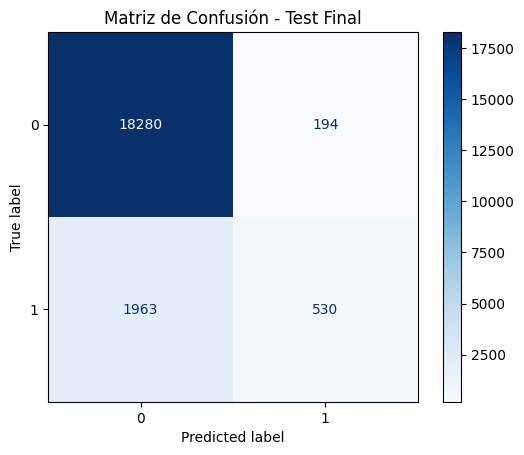

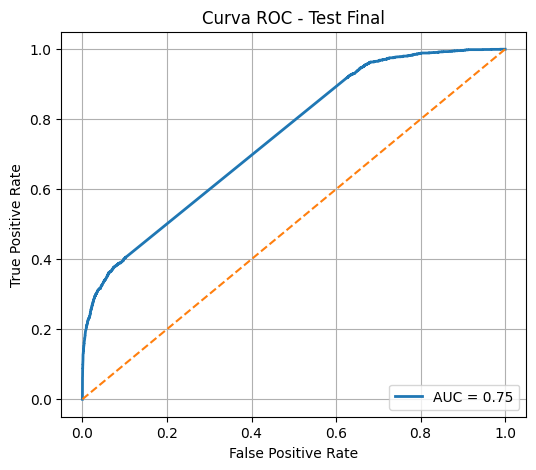

In [21]:
# TEST
y_pred_test_lr = lr.predict(X_test_tfidf)
print("\n TEST FINAL REGRESIÓN LOGÍSTICA ")
print(classification_report(
    y_test,
    y_pred_test_lr
))

# MATRIZ TEST FINAL

cm_test_lr = confusion_matrix(
    y_test,
    y_pred_test_lr
)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_test_lr)
disp.plot(cmap=plt.cm.Blues)
plt.title("Matriz de Confusión - Test Final")
plt.show()

# ROC TEST FINAL

y_score_test_lr = lr.predict_proba(X_test_tfidf)[:,1]
fpr, tpr, _ = roc_curve(
    y_test,
    y_score_test_lr
)

roc_auc = auc(fpr, tpr)
plt.figure(figsize=(6,5))
plt.plot(
    fpr,
    tpr,
    lw=2,
    label=f'AUC = {roc_auc:.2f}'
)

plt.plot(
    [0,1],
    [0,1],
    linestyle='--'
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC - Test Final")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

In [22]:
# EJEMPLOS CORRECTOS E INCORRECTOS

resultados_lr = pd.DataFrame({
    "texto": X_test.reset_index(drop=True),
    "real": y_test.reset_index(drop=True),
    "prediccion": y_pred_test_lr
})

# CORRECTOS

correctos = resultados_lr[resultados_lr["real"] == resultados_lr["prediccion"]]
print("\n")
print("="*60)
print("EJEMPLOS CORRECTOS - LOGISTIC REGRESSION")
print("="*60)

ejemplos_correctos = correctos.sample(
    2,
)

for i, row in ejemplos_correctos.iterrows():

    print(f"\nTEXTO:\n{row['texto']}\n")
    print(f"REAL: {row['real']}")
    print(f"PREDICCIÓN: {row['prediccion']}")
    print("-"*60)

# INCORRECTOS
incorrectos = resultados_lr[
    resultados_lr["real"]
    !=
    resultados_lr["prediccion"]
]

print("\n")
print("="*60)
print("EJEMPLOS INCORRECTOS - LOGISTIC REGRESSION")
print("="*60)

ejemplos_incorrectos = incorrectos.sample(
    2,
)

for i, row in ejemplos_incorrectos.iterrows():

    print(f"\nTEXTO:\n{row['texto']}\n")
    print(f"REAL: {row['real']}")
    print(f"PREDICCIÓN: {row['prediccion']}")
    print("-"*60)



EJEMPLOS CORRECTOS - LOGISTIC REGRESSION

TEXTO:
llama atencion poquisimos siguen cada dia temporada ahora esten muchisimos felices gano

REAL: 0
PREDICCIÓN: 0
------------------------------------------------------------

TEXTO:
cerca toneladas pastura asi mil rollos rastrojo camioneta proteccion civil valle guadalupe quemadas dejo incendio suscitado tarde limites valle guadalupe jalostotitlan informa

REAL: 0
PREDICCIÓN: 0
------------------------------------------------------------


EJEMPLOS INCORRECTOS - LOGISTIC REGRESSION

TEXTO:
puta reina dilo

REAL: 1
PREDICCIÓN: 0
------------------------------------------------------------

TEXTO:
vaya mujer hecha

REAL: 1
PREDICCIÓN: 0
------------------------------------------------------------


## Naive Bayes

In [23]:
nb = MultinomialNB(alpha=0.01)

#Entrena
nb.fit(
    X_train_tfidf,
    y_train
)

,alpha,0.01
,force_alpha,True
,fit_prior,True
,class_prior,None



 VALIDACIÓN NAIVE BAYES 
              precision    recall  f1-score   support

           0       0.90      0.99      0.94      9251
           1       0.70      0.24      0.35      1257

    accuracy                           0.90     10508
   macro avg       0.80      0.61      0.65     10508
weighted avg       0.88      0.90      0.87     10508



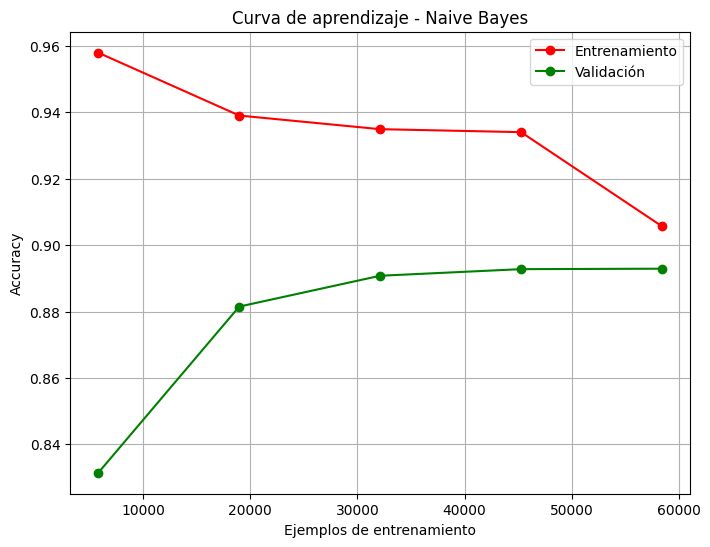

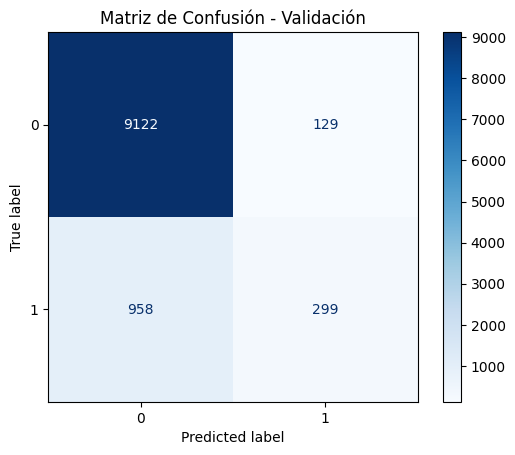

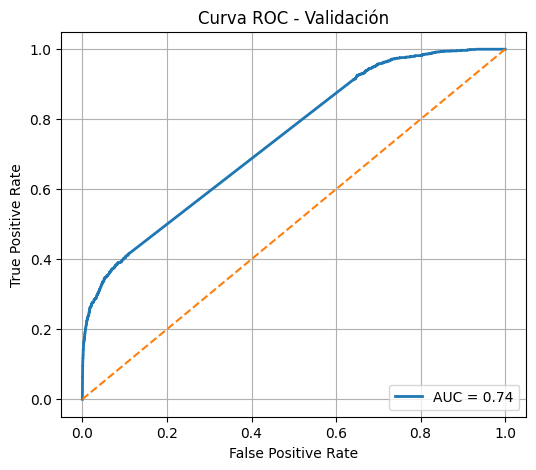

In [24]:
# VALIDACIÓN
y_pred_val_nb = nb.predict(X_val_tfidf)

print("\n VALIDACIÓN NAIVE BAYES ")
print(classification_report(
    y_val,
    y_pred_val_nb
))

# CURVA DE APRENDIZAJE

train_sizes, train_scores, test_scores = learning_curve(
    nb,
    X_train_tfidf,
    y_train,
    cv=5,
    scoring='accuracy',
    train_sizes=np.linspace(
        0.1,
        1.0,
        5
    ),

    n_jobs=-1
)
train_mean_nb = train_scores.mean(axis=1)
test_mean_nb = test_scores.mean(axis=1)
plt.figure(figsize=(8,6))
plt.plot(
    train_sizes,
    train_mean_nb,
    'o-',
    color='red',
    label='Entrenamiento'
)
plt.plot(
    train_sizes,
    test_mean_nb,
    'o-',
    color='green',
    label='Validación'
)

plt.title("Curva de aprendizaje - Naive Bayes")
plt.xlabel("Ejemplos de entrenamiento")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

# MATRIZ DE CONFUSIÓN VALIDACIÓN

cm_val_nb = confusion_matrix(
    y_val,
    y_pred_val_nb
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_val_nb
)
disp.plot(cmap=plt.cm.Blues)
plt.title("Matriz de Confusión - Validación")
plt.show()

# ROC VALIDACIÓN

y_score_val_nb = nb.predict_proba(X_val_tfidf)[:,1]
fpr, tpr, _ = roc_curve(
    y_val,
    y_score_val_nb
)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(6,5))
plt.plot(
    fpr,
    tpr,
    lw=2,
    label=f'AUC = {roc_auc:.2f}'
)

plt.plot(
    [0,1],
    [0,1],
    linestyle='--'
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC - Validación")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


 TEST FINAL NAIVE BAYES 
              precision    recall  f1-score   support

           0       0.90      0.99      0.94     18474
           1       0.69      0.23      0.35      2493

    accuracy                           0.90     20967
   macro avg       0.80      0.61      0.64     20967
weighted avg       0.88      0.90      0.87     20967



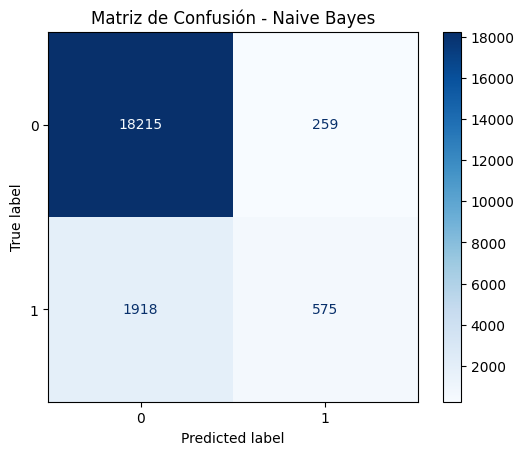

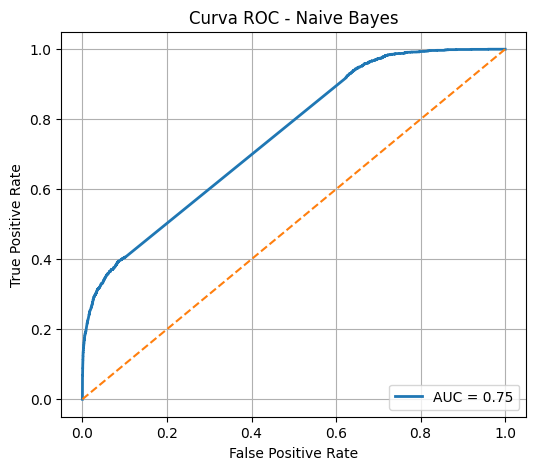

In [25]:
# TEST FINAL

y_pred_nb = nb.predict(X_test_tfidf)
print("\n TEST FINAL NAIVE BAYES ")
print(classification_report(
    y_test,
    y_pred_nb
))

# MATRIZ DE CONFUSIÓN TEST

cm = confusion_matrix(
    y_test,
    y_pred_nb
)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.title("Matriz de Confusión - Naive Bayes")
plt.show()

# ROC TEST FINAL

y_score = nb.predict_proba(X_test_tfidf)[:,1]
fpr, tpr, _ = roc_curve(
    y_test,
    y_score
)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(6,5))
plt.plot(
    fpr,
    tpr,
    lw=2,
    label=f'AUC = {roc_auc:.2f}'
)

plt.plot(
    [0,1],
    [0,1],
    linestyle='--'
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC - Naive Bayes")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

In [26]:
# EJEMPLOS

resultados_nb = pd.DataFrame({
    "texto": X_test.reset_index(drop=True),
    "real": y_test.reset_index(drop=True),
    "prediccion": y_pred_nb
})

# CORRECTOS

correctos = resultados_nb[
    resultados_nb["real"] == resultados_nb["prediccion"]
]

print("\n")
print("="*60)
print("EJEMPLOS CORRECTOS - NAIVE BAYES")
print("="*60)

ejemplos_correctos = correctos.sample(
    2,
)

for i, row in ejemplos_correctos.iterrows():
    print(f"\nTEXTO:\n{row['texto']}\n")
    print(f"REAL: {row['real']}")
    print(f"PREDICCIÓN: {row['prediccion']}")
    print("-"*60)

# INCORRECTOS

incorrectos = resultados_nb[
    resultados_nb["real"] != resultados_nb["prediccion"]
]

print("\n")
print("="*60)
print("EJEMPLOS INCORRECTOS - NAIVE BAYES")
print("="*60)

ejemplos_incorrectos = incorrectos.sample(
    2,
)

for i, row in ejemplos_incorrectos.iterrows():

    print(f"\nTEXTO:\n{row['texto']}\n")
    print(f"REAL: {row['real']}")
    print(f"PREDICCIÓN: {row['prediccion']}")
    print("-"*60)



EJEMPLOS CORRECTOS - NAIVE BAYES

TEXTO:
bola debiles no sirven nada

REAL: 1
PREDICCIÓN: 1
------------------------------------------------------------

TEXTO:
denuncia apoyarla difundirla

REAL: 0
PREDICCIÓN: 0
------------------------------------------------------------


EJEMPLOS INCORRECTOS - NAIVE BAYES

TEXTO:
quiero mames veinte metros bajo tierra

REAL: 1
PREDICCIÓN: 0
------------------------------------------------------------

TEXTO:
gorda ridicula asi t da nafta decirme corrio voz t quedaste miedo pobrecita gringa pelotuda

REAL: 1
PREDICCIÓN: 0
------------------------------------------------------------


## MLP

In [27]:
# CONVERSIÓN A DENSO
X_train_mlp = X_train_tfidf.toarray()
X_val_mlp = X_val_tfidf.toarray()
X_test_mlp = X_test_tfidf.toarray()
y_train_mlp = y_train
y_val_mlp = y_val
y_test_mlp = y_test

In [28]:
# MODELO
mlp = MLPClassifier(
    hidden_layer_sizes=(128, 64),
    activation='relu',
    solver='adam',
    alpha=0.001,
    batch_size=64,
    learning_rate='adaptive',
    max_iter=500,
    random_state=42,
    verbose=True,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=15
)

# ENTRENAMIENTO
mlp.fit(
    X_train_mlp,
    y_train_mlp
)

Iteration 1, loss = 0.33191937
Validation score: 0.896590
Iteration 2, loss = 0.28755806
Validation score: 0.897411
Iteration 3, loss = 0.27929777
Validation score: 0.896726
Iteration 4, loss = 0.27422275
Validation score: 0.893439
Iteration 5, loss = 0.26937990
Validation score: 0.893439
Iteration 6, loss = 0.26514896
Validation score: 0.894124
Iteration 7, loss = 0.26105628
Validation score: 0.892070
Iteration 8, loss = 0.25718876
Validation score: 0.894398
Iteration 9, loss = 0.25401594
Validation score: 0.895357
Iteration 10, loss = 0.25075793
Validation score: 0.893576
Iteration 11, loss = 0.24886902
Validation score: 0.893576
Iteration 12, loss = 0.24676423
Validation score: 0.894809
Iteration 13, loss = 0.24510402
Validation score: 0.895357
Iteration 14, loss = 0.24406563
Validation score: 0.893302
Iteration 15, loss = 0.24275502
Validation score: 0.894946
Iteration 16, loss = 0.24157039
Validation score: 0.893850
Iteration 17, loss = 0.24062622
Validation score: 0.893987
Iterat

,hidden_layer_sizes,"(128, ...)"
,activation,'relu'
,solver,'adam'
,alpha,0.001
,batch_size,64
,learning_rate,'adaptive'
,learning_rate_init,0.001
,power_t,0.5
,max_iter,500
,shuffle,True
,random_state,42



VALIDACIÓN MLP
              precision    recall  f1-score   support

           0       0.90      0.99      0.94      9251
           1       0.73      0.22      0.34      1257

    accuracy                           0.90     10508
   macro avg       0.82      0.61      0.64     10508
weighted avg       0.88      0.90      0.87     10508



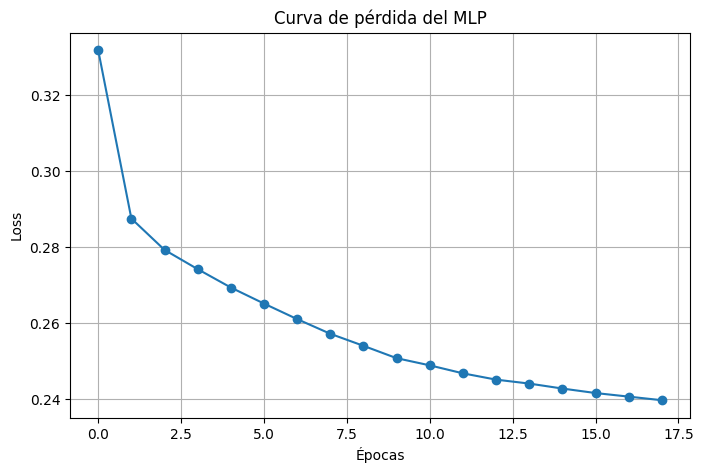

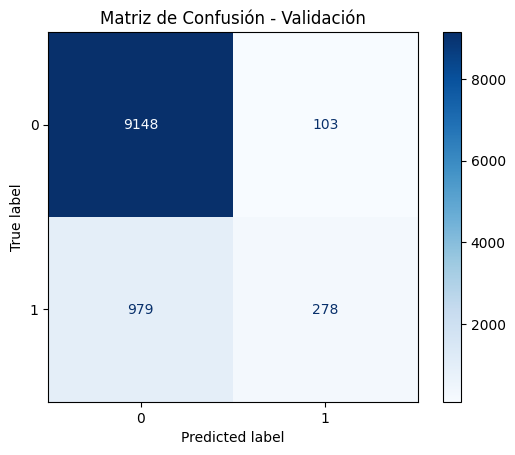

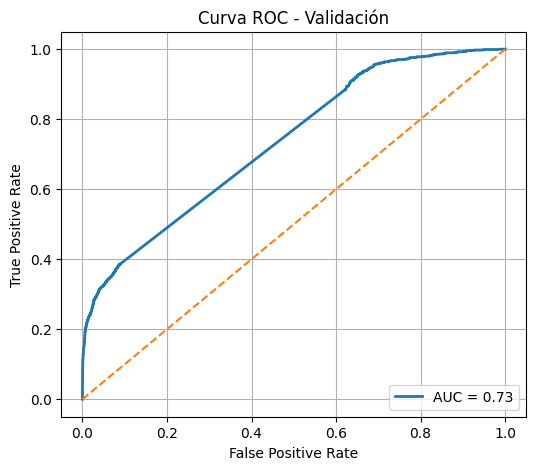

In [29]:
# VALIDACIÓN
y_pred_val_mlp = mlp.predict(
    X_val_mlp
)
print("\nVALIDACIÓN MLP")
print(classification_report(
    y_val_mlp,
    y_pred_val_mlp
))

# CURVA DE PÉRDIDA
plt.figure(figsize=(8,5))
plt.plot(
    mlp.loss_curve_,
    marker='o'
)
plt.title("Curva de pérdida del MLP")
plt.xlabel("Épocas")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

'''# CURVA DE APRENDIZAJE
train_sizes, train_scores, test_scores = learning_curve(
    mlp,
    X_train_mlp,
    y_train_mlp,
    cv=5,
    scoring='accuracy',
    train_sizes=np.linspace(
        0.1,
        1.0,
        5
    ),

    n_jobs=1
)
train_mean = train_scores.mean(axis=1)
test_mean = test_scores.mean(axis=1)
plt.figure(figsize=(8,6))
plt.plot(
    train_sizes,
    train_mean,
    'o-',
    color='red',
    label='Entrenamiento'
)

plt.plot(
    train_sizes,
    test_mean,
    'o-',
    color='green',
    label='Validación cruzada'
)
plt.title("Curva de aprendizaje del MLP")
plt.xlabel("Ejemplos de entrenamiento")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()'''

# MATRIZ VALIDACIÓN

cm_val = confusion_matrix(
    y_val_mlp,
    y_pred_val_mlp
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_val
)
disp.plot(cmap=plt.cm.Blues)
plt.title("Matriz de Confusión - Validación")
plt.show()

# ROC VALIDACIÓN

y_score_val = mlp.predict_proba(
    X_val_mlp
)[:,1]

fpr, tpr, _ = roc_curve(
    y_val_mlp,
    y_score_val
)

roc_auc = auc(fpr, tpr)
plt.figure(figsize=(6,5))
plt.plot(
    fpr,
    tpr,
    lw=2,
    label=f'AUC = {roc_auc:.2f}'
)

plt.plot(
    [0,1],
    [0,1],
    linestyle='--'
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC - Validación")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()



TEST FINAL MLP
              precision    recall  f1-score   support

           0       0.90      0.99      0.94     18474
           1       0.71      0.21      0.33      2493

    accuracy                           0.90     20967
   macro avg       0.81      0.60      0.63     20967
weighted avg       0.88      0.90      0.87     20967



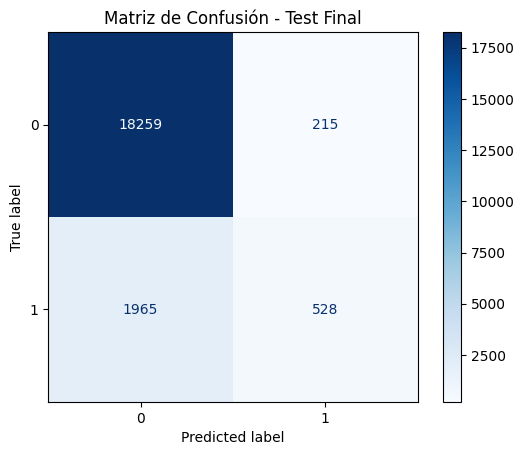

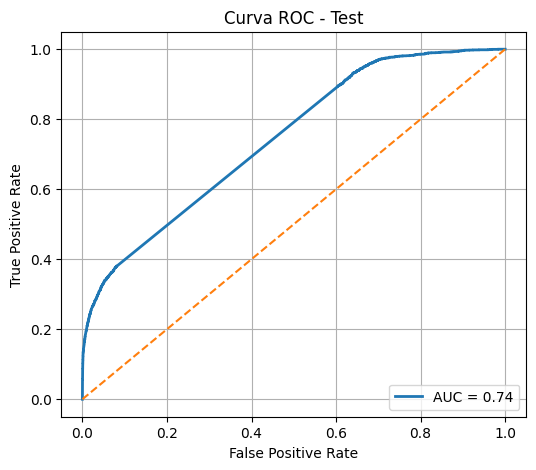

In [30]:
# TEST FINAL
y_pred_test_mlp = mlp.predict(
    X_test_mlp
)

print("\nTEST FINAL MLP")
print(classification_report(
    y_test_mlp,
    y_pred_test_mlp
))


# MATRIZ TEST FINAL

cm_test = confusion_matrix(
    y_test_mlp,
    y_pred_test_mlp
)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_test
)
disp.plot(cmap=plt.cm.Blues)
plt.title("Matriz de Confusión - Test Final")
plt.show()

# ROC TEST FINAL

y_score_test = mlp.predict_proba(
    X_test_mlp
)[:,1]

fpr, tpr, _ = roc_curve(
    y_test_mlp,
    y_score_test
)

roc_auc = auc(fpr, tpr)
plt.figure(figsize=(6,5))
plt.plot(
    fpr,
    tpr,
    lw=2,
    label=f'AUC = {roc_auc:.2f}'
)

plt.plot(
    [0,1],
    [0,1],
    linestyle='--'
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC - Test")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

In [ ]:
# EJEMPLOS CORRECTOS E INCORRECTOS
resultados_mlp = pd.DataFrame({
    "texto": X_test.reset_index(drop=True),
    "real": y_test_mlp.reset_index(drop=True),
    "prediccion": y_pred_test_mlp
})

# CORRECTOS

correctos = resultados_mlp[resultados_mlp["real"] == resultados_mlp["prediccion"]]
print("\n")
print("="*60)
print("EJEMPLOS CORRECTOS - MLP")
print("="*60)

ejemplos_correctos = correctos.sample(
    2,
)

for i, row in ejemplos_correctos.iterrows():
    print(f"\nTEXTO:\n{row['texto']}\n")
    print(f"REAL: {row['real']}")
    print(f"PREDICCIÓN: {row['prediccion']}")
    print("-"*60)


# INCORRECTOS

incorrectos = resultados_mlp[resultados_mlp["real"] != resultados_mlp["prediccion"]]
print("\n")
print("="*60)
print("EJEMPLOS INCORRECTOS - MLP")
print("="*60)

ejemplos_incorrectos = incorrectos.sample(
    2,
)

for i, row in ejemplos_incorrectos.iterrows():
    print(f"\nTEXTO:\n{row['texto']}\n")
    print(f"REAL: {row['real']}")
    print(f"PREDICCIÓN: {row['prediccion']}")
    print("-"*60)



EJEMPLOS CORRECTOS - MLP

TEXTO:
no queremos zapatos localizan muerta menor

REAL: 0
PREDICCIÓN: 0
------------------------------------------------------------

TEXTO:
destituye cabildo secretaria desarrollo economico eaucalpan

REAL: 0
PREDICCIÓN: 0
------------------------------------------------------------


EJEMPLOS INCORRECTOS - MLP

TEXTO:
pacto federal bonilla criminal da asco

REAL: 0
PREDICCIÓN: 1
------------------------------------------------------------

TEXTO:
recogete estupida

REAL: 1
PREDICCIÓN: 0
------------------------------------------------------------
